In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
data = pd.read_csv('tvbs_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True)
data.head(10)

,Title,Context,PublishTime
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025/06/12 15:50
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025/06/08 20:53
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025/05/21 13:10
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025/05/21 12:49
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025/05/20 17:11
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,用路人注意！為進行排水改善並復原路面施工，台9線蘇花改「中仁隧道南下線」自今（13）日上午起...,2025/05/13 11:56
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,清明4天連假即將到來，交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主，省道主要幹道及...,2025/04/01 09:45
7,騎士檢舉違規遭退件 控警消極未通知補件,上個月初，有機車騎士在蘇花公路，差點被對向一輛跨越雙黃線的休旅車撞上，騎士隔天上網檢舉，不過...,2025/01/03 18:36
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024/12/02 14:30
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024/11/02 17:46


In [74]:
data['PublishTime'] = pd.to_datetime(data['PublishTime'], format='%Y/%m/%d %H:%M', errors='coerce')

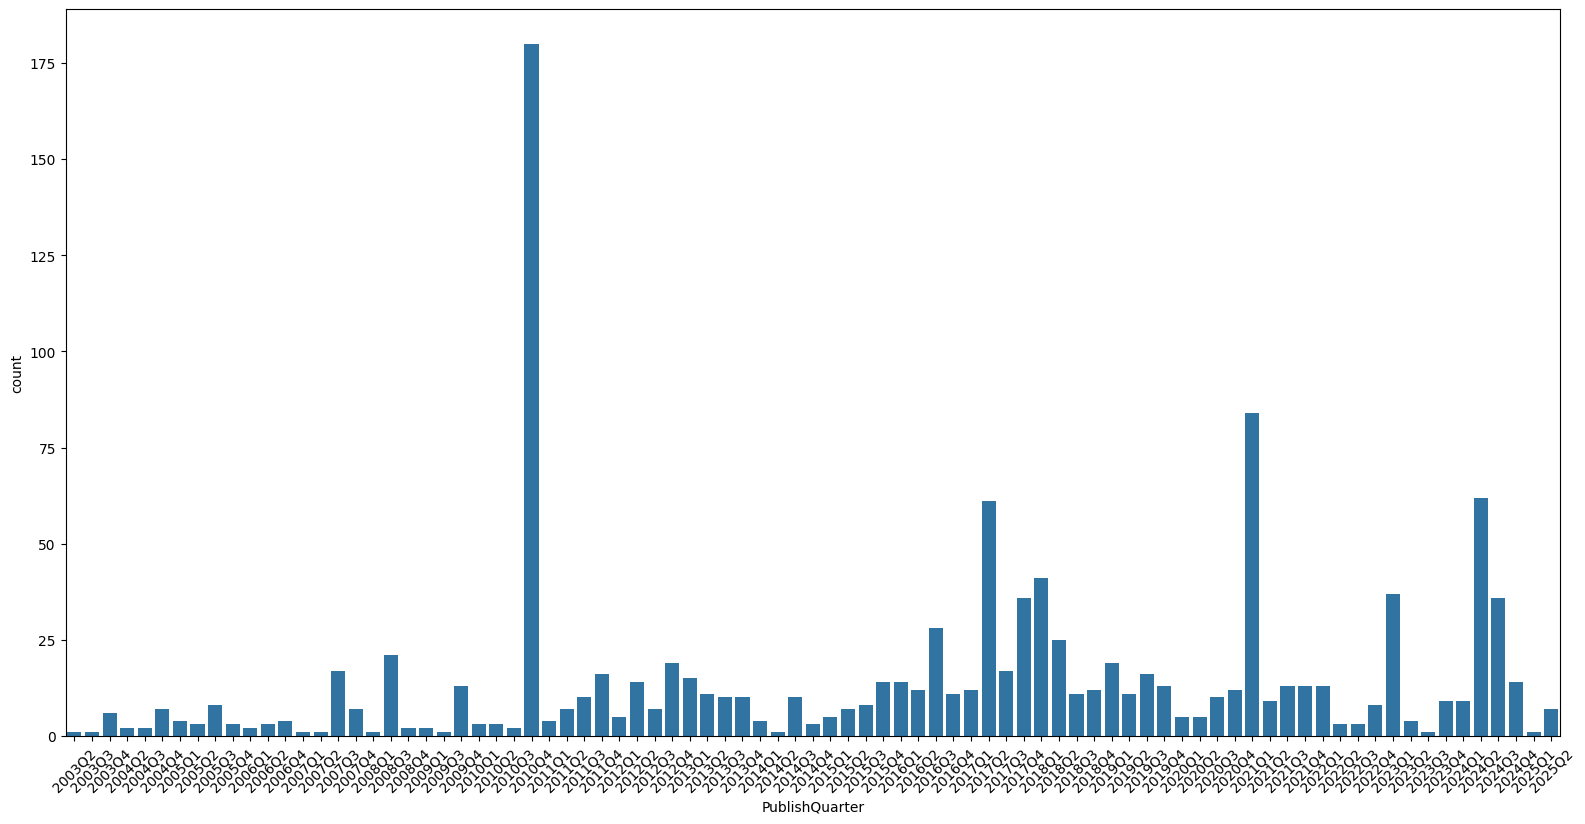

In [75]:
data['PublishQuarter'] = data['PublishTime'].dt.to_period('Q').astype(str)
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [76]:
text_all = '\n'.join(data['Context'].dropna())

In [77]:
import jieba, re, string

In [111]:
fullwidth_punctuation = "，。！？：；「」『』（）〔〕【】《》—…～‧、．"
all_punct = string.punctuation + fullwidth_punctuation
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = text.translate(str.maketrans('', '', all_punct))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text)                               # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                 # 刪網址
    text = re.sub(r'<.*?>+', '', text)                                # 刪 HTML tag
    text = re.sub(r'\n', ' ', text)                                   # 換行→空白
    # text = re.sub(r'\w*\d\w*', ' ', text)                             # 含數字詞
    text = re.sub(r'\d+', ' ', text)                                  # 數字
    text = re.sub(r'\s+', ' ', text).strip()                          # 連續空白
    return text
data["Cleaned_Context"] = data["Context"].apply(clean_text)
data.head(10)

,Title,Context,PublishTime,PublishQuarter,Cleaned_Context,Tokens
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025-06-12 15:50:00,2025Q2,受到昨 日東部規模 地震及熱帶低壓降雨影響中橫公路台 線 k豁然亭路段今 日下午 時許上邊坡...,"[受到, 昨, , 日, 東部, 規模, , 地震, 及, 熱帶, 低壓, 降雨, 影響..."
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025-06-08 20:53:00,2025Q2,花蓮地區下午到晚上期間大雨與雷聲不間斷有 名學生到知名景點砂婆噹戲水返程時遇到溪水暴漲受困等...,"[花蓮, 地區, 下午, 到, 晚上, 期間, 大雨, 與, 雷聲, 不, 間斷, 有, ..."
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025-05-21 13:10:00,2025Q2,近日豪雨影響花蓮北上鐵公路再度中斷導致交通受阻縣長徐榛蔚今天攜手多位議員及觀光產業界公開向總...,"[近日, 豪雨, 影響, 花蓮, 北上, 鐵公路, 再度, 中斷, 導致, 交通, 受阻, ..."
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025-05-21 12:49:00,2025Q2,台鐵北迴線受到大雨影響兩度雙向中斷無法通行昨天連蘇花公路都受影響台鐵宣布在今天清晨 點多總算...,"[台鐵, 北迴線, 受到, 大雨, 影響, 兩度, 雙向, 中斷, 無法, 通行, 昨天, ..."
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025-05-20 17:11:00,2025Q2,花蓮縣 日下午受到對流雲系發展旺盛影響下起傾盆大雨導致台鐵和仁崇德遭土石流淹沒軌道北迴線雙向...,"[花蓮縣, , 日, 下午, 受到, 對流雲系, 發展, 旺盛, 影響, 下起, 傾盆大雨..."
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,用路人注意！為進行排水改善並復原路面施工，台9線蘇花改「中仁隧道南下線」自今（13）日上午起...,2025-05-13 11:56:00,2025Q2,用路人注意為進行排水改善並復原路面施工台 線蘇花改中仁隧道南下線自今 日上午起到 月 日下午...,"[用, 路人, 注意, 為, 進行, 排水, 改善, 並, 復原, 路面, 施工, 台, ..."
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,清明4天連假即將到來，交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主，省道主要幹道及...,2025-04-01 09:45:00,2025Q2,清明 天連假即將到來交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主省道主要幹道及各地...,"[清明, , 天, 連假, 即將, 到來, 交通部, 公路局, 預估, 本次, 連假, 車..."
7,騎士檢舉違規遭退件 控警消極未通知補件,上個月初，有機車騎士在蘇花公路，差點被對向一輛跨越雙黃線的休旅車撞上，騎士隔天上網檢舉，不過...,2025-01-03 18:36:00,2025Q1,上個月初有機車騎士在蘇花公路差點被對向一輛跨越雙黃線的休旅車撞上騎士隔天上網檢舉不過卻被退件...,"[上個, 月, 初, 有, 機車, 騎士, 在, 蘇花公路, 差點, 被, 對, 向, 一輛..."
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024-12-02 14:30:00,2024Q4,今 日中午 時許宜蘭縣南澳鄉台九丁線 公里處南下發生火燒車意外車上 歲趙姓男駕駛與姊姊從桃園...,"[今, , 日, 中午, , 時許, 宜蘭縣, 南澳鄉, 台九, 丁線, , 公里, ..."
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024-11-02 17:46:00,2024Q4,康芮颱風侵襲帶來許多災情在蘇花公路匯德隧道北口發生土石流高達 萬 千立方公尺的土石掩埋道路公...,"[康芮, 颱風, 侵襲, 帶來, 許多, 災情, 在, 蘇花公路, 匯德, 隧道, 北口, ..."


In [107]:
def tokenize(text):
    if pd.isna(text):
        return []
    return list(jieba.cut(text))

data['Tokens'] = data['Cleaned_Context'].apply(tokenize)

In [108]:
data

,Title,Context,PublishTime,PublishQuarter,Cleaned_Context,Tokens
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025-06-12 15:50:00,2025Q2,受到昨 日東部規模 地震及熱帶低壓降雨影響中橫公路台 線 k豁然亭路段今 日下午 時許上邊坡...,"[受到, 昨, , 日, 東部, 規模, , 地震, 及, 熱帶, 低壓, 降雨, 影響..."
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025-06-08 20:53:00,2025Q2,花蓮地區下午到晚上期間大雨與雷聲不間斷有 名學生到知名景點砂婆噹戲水返程時遇到溪水暴漲受困等...,"[花蓮, 地區, 下午, 到, 晚上, 期間, 大雨, 與, 雷聲, 不, 間斷, 有, ..."
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025-05-21 13:10:00,2025Q2,近日豪雨影響花蓮北上鐵公路再度中斷導致交通受阻縣長徐榛蔚今天攜手多位議員及觀光產業界公開向總...,"[近日, 豪雨, 影響, 花蓮, 北上, 鐵公路, 再度, 中斷, 導致, 交通, 受阻, ..."
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025-05-21 12:49:00,2025Q2,台鐵北迴線受到大雨影響兩度雙向中斷無法通行昨天連蘇花公路都受影響台鐵宣布在今天清晨 點多總算...,"[台鐵, 北迴線, 受到, 大雨, 影響, 兩度, 雙向, 中斷, 無法, 通行, 昨天, ..."
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025-05-20 17:11:00,2025Q2,花蓮縣 日下午受到對流雲系發展旺盛影響下起傾盆大雨導致台鐵和仁崇德遭土石流淹沒軌道北迴線雙向...,"[花蓮縣, , 日, 下午, 受到, 對流雲系, 發展, 旺盛, 影響, 下起, 傾盆大雨..."
...,...,...,...,...,...,...
1172,豪雨不斷蘇花坍方 中午恢復通車,受到豪雨影響，宜蘭蘇花公路140.6公里南澳路段，上午嚴重坍方，工務單位搶救三個半小時，中午...,2003-11-28 16:17:00,2003Q4,受到豪雨影響宜蘭蘇花公路 公里南澳路段上午嚴重坍方工務單位搶救三個半小時中午恢復雙向通車另外...,"[受到, 豪雨, 影響, 宜蘭, 蘇花公路, , 公里, 南澳, 路段, 上午, 嚴重, ..."
1173,蘇花公路140.6公里處 坍方30公尺,上午七點多，蘇花公路140.6公里處，因為連夜大雨，坍方30公尺，造成雙向全線中斷，許多車輛...,2003-11-28 11:15:00,2003Q4,上午七點多蘇花公路 公里處因為連夜大雨坍方 公尺造成雙向全線中斷許多車輛無法通行回堵兩三公里...,"[上午, 七點, 多, 蘇花公路, , 公里, 處, 因為, 連夜, 大雨, 坍方, ,..."
1174,蘇花隧道機車撞卡車 2騎士死亡,台九線蘇花公路崇德隧道口，深夜一輛機車疑似超速失控，迎面撞上對向行駛的一部砂石車，肇事的兩名...,2003-11-04 07:20:00,2003Q4,台九線蘇花公路崇德隧道口深夜一輛機車疑似超速失控迎面撞上對向行駛的一部砂石車肇事的兩名騎士當...,"[台九線, 蘇花公路, 崇德, 隧道口, 深夜, 一輛, 機車, 疑似, 超速, 失控, 迎..."
1175,蘇花和仁164公里處坍方 單線通車,蘇花公路又傳坍方，在和仁段164公里處，因為巨石砸毀道路，工程單位緊急搶修，目前單線通車，預...,2003-07-11 13:01:00,2003Q3,蘇花公路又傳坍方在和仁段 公里處因為巨石砸毀道路工程單位緊急搶修目前單線通車預計到傍晚能夠恢...,"[蘇花公路, 又, 傳, 坍方, 在, 和, 仁段, , 公里, 處, 因為, 巨石, 砸..."


In [114]:
with open('停用詞-繁體中文.txt', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f)

In [112]:
def tokenize_filtered(text):
    if pd.isna(text):
        return []
    tokens = jieba.cut(text)
    return [ t for t in tokens if t not in stopwords and len(t)>1 and t.isalpha()]

In [115]:
data['Tokens'] = data['Cleaned_Context'].apply(tokenize_filtered)

In [117]:
data[['Title', 'Tokens']].head(10)


,Title,Tokens
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,"[受到, 東部, 規模, 地震, 熱帶, 低壓, 降雨, 影響, 中橫公路台, 路段, 下午..."
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,"[花蓮, 地區, 下午, 晚上, 期間, 大雨, 雷聲, 間斷, 學生, 知名, 景點, 砂..."
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,"[近日, 豪雨, 影響, 花蓮, 北上, 鐵公路, 再度, 中斷, 導致, 交通, 受阻, ..."
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,"[台鐵, 北迴線, 受到, 大雨, 影響, 兩度, 雙向, 中斷, 無法, 通行, 昨天, ..."
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,"[花蓮縣, 下午, 受到, 對流雲系, 發展, 旺盛, 影響, 下起, 傾盆大雨, 導致, ..."
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,"[路人, 注意, 進行, 排水, 改善, 復原, 路面, 施工, 蘇花, 中仁, 隧道, 南..."
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,"[清明, 連假, 到來, 交通部, 公路局, 預估, 本次, 連假, 車潮, 將以, 掃墓,..."
7,騎士檢舉違規遭退件 控警消極未通知補件,"[上個, 機車, 騎士, 蘇花公路, 差點, 一輛, 跨越, 雙黃線, 休旅車, 撞上, 騎..."
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,"[中午, 時許, 宜蘭縣, 南澳鄉, 台九, 丁線, 公里, 南下, 發生, 火燒車, 意外..."
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,"[康芮, 颱風, 侵襲, 帶來, 許多, 災情, 蘇花公路, 匯德, 隧道, 北口, 發生,..."


In [119]:
from collections import Counter
all_tokens = [token for tokens in data['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)
top_tf = word_freq.most_common(30)

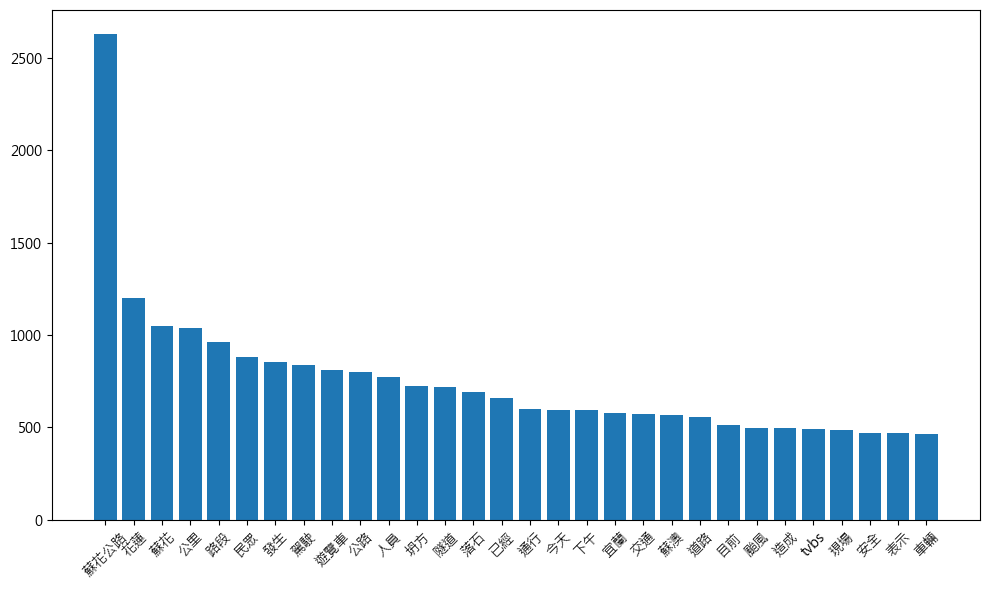

In [124]:
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
words, freqs = zip(*top_tf)
plt.figure(figsize=(10, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [125]:
data['Joined_Tokens'] = data['Tokens'].apply(lambda x: ' '.join(x))
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(data['Joined_Tokens'])
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


<Axes: >

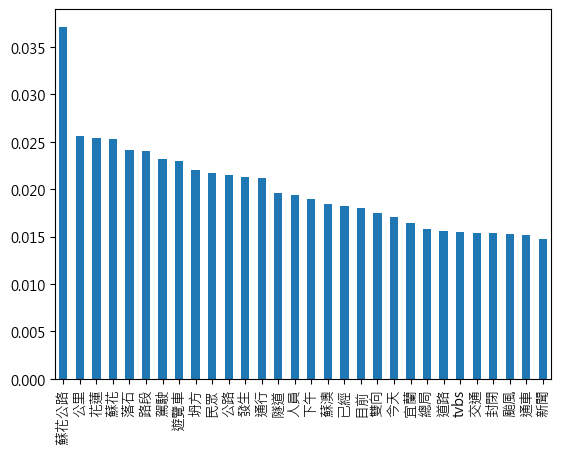

In [126]:
mead_tfidf = tfidf_df.mean().sort_values(ascending=False)
top_tfidf = mead_tfidf.head(30)
top_tfidf.plot(kind='bar')